# 04. Supervisor 패턴 — 구조화 출력 라우팅 방식

> 이 노트북은 `02-Supervisor.ipynb`의 **핸드오프 도구 방식**과 짝을 이루는 **구조화 출력 라우팅 방식**을 다뤄요.
>
> | 레슨 | Supervisor가 다음 노드를 고르는 방법 | 대표 기술 |
> |------|-------------------------------------|----------|
> | **02-Supervisor** | 핸드오프 **도구 호출** (`transfer_to_X`) | `create_supervisor`, `create_handoff_tool`, `Command(goto=..., graph=PARENT)` |
> | **04-Multi-Agent-Supervisor (이 노트북)** | **구조화된 출력**으로 다음 노드 이름을 직접 반환 | `RouteResponse(next: Literal[...])`, `with_structured_output`, `add_conditional_edges` |
>
> 두 방식은 같은 "Supervisor + Worker" 아키텍처를 다른 메커니즘으로 구현한 것이에요. 어느 하나가 낡은 방식이 아니라, 실전에서 **어느 상황에 무엇을 쓸지** 판단할 수 있도록 둘 다 알아두는 게 핵심이에요. 이 노트북 마지막 비교표에서 선택 기준을 정리해요.

## 학습 목표

이 노트북을 마치면 다음을 할 수 있어요:

1. Supervisor 패턴을 **구조화된 출력(`RouteResponse`)으로 라우팅**하는 방식의 원리를 설명하고, 02 노트북의 핸드오프 도구 방식과 구조적으로 비교할 수 있어요
2. `Literal[*options]` 타입을 활용해 Supervisor가 항상 **유효한 라우팅 선택지**만 반환하도록 강제할 수 있어요
3. `functools.partial`로 `agent_node` 함수에 에이전트와 이름을 바인딩해 재사용 가능한 노드를 만들 수 있어요
4. StateGraph 방식(명시적 `conditional_map`)과 Agent-as-Tool 방식(LLM 자율 라우팅)을 각각 구현하고 두 방식을 비교할 수 있어요

## 사전 지식

- `02-Supervisor.ipynb` — 핸드오프 도구 방식의 Supervisor (비교 대상)
- `03-Multi-Agent-Collaboration.ipynb` — 에이전트 간 도구 기반 협업의 기초
- Part 5 `create_agent` 기반 에이전트 생성
- `StateGraph`, `add_conditional_edges`, `with_structured_output` 등 LangGraph 그래프 구성 API

## Supervisor 패턴 개요 — 02와 04는 무엇이 다른가

`02-Supervisor`와 이 노트북은 **같은 아키텍처**(Supervisor가 Worker를 조율)를 공유하지만, Supervisor LLM이 "다음은 누가 일할 차례인가"를 결정하는 **메커니즘**이 달라요.

```
[02-Supervisor]                         [04 이 노트북]
Supervisor LLM                          Supervisor LLM
    │                                       │
    ▼ (tool call)                           ▼ (structured output)
transfer_to_research_agent(...)         RouteResponse(next="Researcher")
    │                                       │
    ▼                                       ▼
Command(goto="research_agent")          conditional_map[next] → "Researcher"
    │                                       │
    ▼                                       ▼
research_agent 노드 실행                research_node 실행
```

> 💡 **왜 두 방식이 공존할까요?**
> - **핸드오프 도구(02)**: 자연스러운 "도구 호출" 사고방식과 어울려요. `Command`로 상태·메시지를 함께 전달할 수 있어 고급 핸드오프(task description, subgraph 이동)에 강해요.
> - **구조화 출력(04)**: Supervisor의 결정을 **엄격한 enum**으로 타입 안전하게 고정해요. LLM이 "research 에이전트가 필요해 보여요"처럼 자유 서술하지 못하고 `Literal` 중 하나만 뱉도록 강제되므로 디버깅·관찰이 쉬워요. 도구 호출이 지원되지 않는 환경에서도 작동해요.

이 노트북의 Supervisor의 핵심 역할은 여전히 세 가지예요.

| 역할 | 설명 |
|------|------|
| **작업 분배** | 사용자 요청을 분석해 가장 적합한 전문가 에이전트에게 작업을 할당해요 |
| **진행 모니터링** | 각 에이전트의 실행 결과를 보고 다음 단계를 결정해요 |
| **종료 판단** | 모든 작업이 완료되면 `FINISH`를 반환해 워크플로우를 끝내요 |

이 노트북에서는 구조화 출력 라우팅을 **두 가지 구현 형태**로 보여줘요.

| 형태 | 핵심 요소 | 특징 |
|------|----------|------|
| **StateGraph 방식** | `RouteResponse` + `add_conditional_edges` | 명시적 흐름 제어, 세밀한 커스터마이징 |
| **Agent-as-Tool 방식** | `@tool` 래핑 + `create_agent` | 간결한 코드, 빠른 프로토타이핑 |

> 🔑 **핵심 개념**: `with_structured_output(RouteResponse)`는 LLM이 항상 유효한 에이전트 이름 또는 `FINISH`만 반환하도록 제약해요. 이것이 무한 루프와 라우팅 오류를 막는 1차 방어선이에요.

### 시스템 아키텍처 (StateGraph 방식)

```mermaid
flowchart TD
    U(["사용자 입력<br>User Input"]) --> S
    S(["Supervisor<br>라우팅 결정"]) --> R
    S --> C
    S --> FIN(["END<br>종료"])
    R(["Researcher<br>웹 검색"]) --> S
    C(["Coder<br>Python 실행"]) --> S

    classDef input fill:#d4edda,stroke:#28a745,color:#155724
    classDef process fill:#cce5ff,stroke:#007bff,color:#004085
    classDef output fill:#fff3cd,stroke:#ffc107,color:#856404
    classDef storage fill:#e2d5f1,stroke:#6f42c1,color:#3d1f6e

    class U input
    class S storage
    class R,C process
    class FIN output
```

각 Worker 에이전트는 작업 완료 후 반드시 Supervisor로 돌아와요. Supervisor가 `FINISH`를 반환할 때까지 이 사이클이 반복돼요.

## 환경 설정

In [1]:
# ---------------------------------------------------
# 환경 변수 로드
# ---------------------------------------------------
# .env 파일에서 OPENAI_API_KEY, TAVILY_API_KEY 등을 불러와요
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
# ---------------------------------------------------
# LangSmith 추적 설정 (선택 사항)
# ---------------------------------------------------
# 실행 추적을 원하면 아래 주석을 해제하세요
import os

# os.environ["LANGCHAIN_TRACING_V2"] = "true"
# os.environ["LANGCHAIN_PROJECT"] = "Multi-Agent-Supervisor"

## 모델 설정

LangChain V1의 `init_chat_model`을 사용해 모델을 초기화해요. 기본 모델은 비용 효율적인 `gpt-4o-mini`를 사용해요.

In [3]:
# ---------------------------------------------------
# 모델 초기화
# ---------------------------------------------------
from langchain.chat_models import init_chat_model

# 기본 모델: gpt-4o-mini (비용 효율, 학생 접근성)
# 다른 모델로 변경하려면:
#   Anthropic: "anthropic:claude-sonnet-4-5"
#   Ollama 로컬: "ollama:llama3"
model = init_chat_model("openai:gpt-4o-mini")
# 모델 초기화 완료: gpt-4o-mini

## 1. 상태(State) 정의

멀티 에이전트 시스템에서 모든 에이전트는 같은 상태(State)를 공유해요. `AgentState`는 두 개의 필드로 구성돼요.

| 필드 | 타입 | 역할 |
|------|------|------|
| `messages` | `Annotated[Sequence[BaseMessage], operator.add]` | 전체 대화 기록 (자동 누적) |
| `next` | `str` | 다음으로 실행할 에이전트 이름 |

> 🔑 **핵심 개념**: `operator.add`를 reducer로 지정하면 각 노드가 반환한 메시지가 기존 목록에 **추가(append)**돼요. 덮어쓰지 않으므로 전체 대화 이력이 보존돼요.

> 💡 **실무 팁**: `next` 필드는 Supervisor가 채워 넣는 라우팅 지시서예요. Worker 에이전트는 이 필드를 읽지 않고, `conditional_map`이 이 값을 보고 다음 노드를 결정해요.

In [4]:
import operator
from typing import Sequence, Annotated
from typing_extensions import TypedDict
from langchain_core.messages import BaseMessage

class AgentState(TypedDict):
    """멀티 에이전트 시스템 공유 상태"""
    messages: Annotated[Sequence[BaseMessage], operator.add]
    next: str


## 2. Worker 에이전트와 도구(Tool) 생성

이번 예제에서는 두 명의 전문가 Worker를 만들어요.

| Worker | 도구 | 역할 |
|--------|------|------|
| **Researcher** | `TavilySearch` | 웹 검색으로 정보와 데이터를 수집해요 |
| **Coder** | `python_repl_tool` | Python 코드를 작성하고 실행해요 |

> ⚠️ **자주 하는 실수**: `python_repl_tool`은 코드를 실제로 실행하는 도구예요. 출력을 확인하려면 반드시 `print()`를 사용해야 해요. `return` 문으로는 결과가 보이지 않아요.

In [5]:
# ---------------------------------------------------
# 도구(Tool) 정의
# ---------------------------------------------------
import io
import sys
from typing import Annotated

from langchain_tavily import TavilySearch
from langchain.tools import tool

# Tavily 검색 도구: 최대 5개의 웹 검색 결과를 반환해요
tavily_tool = TavilySearch(max_results=5)


def _run_python_code(code: str) -> str:
    """Python 코드를 안전하게 실행하고 stdout 출력을 반환하는 내부 함수예요"""
    old_stdout = sys.stdout
    sys.stdout = buffer = io.StringIO()
    try:
        exec(code, {})
    except Exception as e:
        sys.stdout = old_stdout
        return f"Error: {repr(e)}"
    sys.stdout = old_stdout
    return buffer.getvalue()


@tool
def python_repl_tool(
    code: Annotated[str, "실행할 Python 코드. print()로 결과를 출력해야 해요."],
) -> str:
    """Python 코드를 실행해요. 결과를 보려면 반드시 print(...)를 사용하세요."""
    try:
        result = _run_python_code(code)
    except BaseException as e:
        return f"코드 실행 실패. 오류: {repr(e)}"
    return result

/Users/elixir/dev/lecture/hk-toss/10_langgraph/.venv/lib/python3.14/site-packages/langgraph/checkpoint/serde/encrypted.py:5: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


### agent_node 함수와 functools.partial

`agent_node`는 Worker 에이전트를 StateGraph에 연결하는 어댑터 함수예요. 하나의 함수를 `functools.partial`로 여러 에이전트에 재사용할 수 있어요.

```python
# partial 없이 직접 호출할 때
agent_node(state, agent=research_agent, name="Researcher")

# partial 사용 후: state만 전달
research_node = functools.partial(agent_node, agent=research_agent, name="Researcher")
research_node(state)  # 이렇게 깔끔하게 호출 가능해요
```

> 💡 **핵심 정리**: `agent_node` 안에서 `AIMessage(name=name)`으로 변환하는 이유를 짚어봐요. StateGraph의 `messages` 필드는 `BaseMessage` 타입이지만, 메시지에 `name` 속성을 붙여 어떤 에이전트가 생성한 메시지인지 추적할 수 있어요.

In [6]:
import functools
from langchain.messages import HumanMessage, AIMessage
from langchain.agents import create_agent

def agent_node(state: AgentState, agent, name: str) -> dict:
    """에이전트를 실행하고 결과를 AIMessage로 변환해 반환한다."""
    agent_response = agent.invoke(state)

    return {
        "messages": [AIMessage(content=agent_response["messages"][-1].content)]
    }

research_agent = create_agent(
    model="openai:gpt-4o-mini",
    tools=[tavily_tool],
    system_prompt=(
        "You can only do research. "
        "You are working with a coder colleague who will handle data visualization."
    )
)

research_node = functools.partial(agent_node, agent=research_agent, name="Researcher")


In [7]:
# ---------------------------------------------------
# Research Agent 동작 테스트
# ---------------------------------------------------
# 간단한 검색 요청으로 Research Agent가 정상 동작하는지 확인해요
test_result = research_node(
    {
        "messages": [
            HumanMessage(content="한국의 2024년 GDP를 간단히 알려주세요.")
        ]
    }
)

# === Research Agent 테스트 결과 ===
print(f"응답 에이전트: {test_result['messages'][-1].name}")
print(f"응답 내용:\n{test_result['messages'][-1].content[:300]}...")

응답 에이전트: None
응답 내용:
2024년 한국의 GDP는 다음과 같이 예상됩니다:

1. **실질 GDP 성장률**: 2.0% (예상치)
2. **명목 GDP**: 약 2,532조 원 (2024년 기준)
3. **소비**: 1.1% 증가 예상
4. **정부 소비**: 2.1% 증가 예상
5. **수출**: 6.8% 증가 예상, 주요 원인은 반도체 수요 회복

한국 경제는 2024년에도 계속해서 회복세를 보일 것으로 전망되고 있습니다. [IMF 보고서](https://www.imf.org/en/news/articles/2025/02/06/pr-2530-korea-...


## 3. Supervisor Agent 생성

Supervisor는 현재 대화 상태를 보고 다음 Worker를 결정하는 LLM 기반 라우터예요.

### RouteResponse - 타입 안전 라우팅

`RouteResponse`는 Supervisor의 응답을 제한하는 Pydantic 모델이에요. `Literal[*options]`를 사용해 유효한 선택지만 반환하도록 강제해요.

```python
options_for_next = ["FINISH", "Researcher", "Coder"]

class RouteResponse(BaseModel):
    next: Literal["FINISH", "Researcher", "Coder"]
```

> 🔑 **핵심 개념**: `model.with_structured_output(RouteResponse)`를 사용하면 LLM이 항상 유효한 에이전트 이름만 반환해요. LLM이 "저는 Researcher를 선택하겠습니다"처럼 자유 텍스트로 응답하는 것을 막아줘요.

> ⚠️ **자주 하는 실수**: `members` 목록에 에이전트를 추가할 때 `options_for_next`도 함께 업데이트해야 해요. 그렇지 않으면 새 에이전트로 라우팅되지 않아요.

In [8]:
from pydantic import BaseModel
from typing import Literal

members = ["Researcher", "Coder"]

options_for_next = ["FINISH"] + members

class RouteResponse(BaseModel):
    """
    Superbisor의 라우팅 응답 모델

    Literal 타입으로 유효한 선택지만 반환하도록 제약.
    LLM이 임의의 텍스트를 반환하는 것을 막아준다.
    """

    next: Literal[*options_for_next]

In [9]:
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

# 시스템 프롬프트: Supervisor의 역할과 각 Worker의 전문 분야를 명시해요
system_prompt = (
    "You are a supervisor tasked with managing a conversation between the"
    " following workers: {members}.\n"
    " Researcher: searches the web for information and returns raw data.\n"
    " Coder: writes and executes Python code for data analysis and visualization.\n"
    " Given the following user request,"
    " respond with the worker to act next. Each worker will perform a"
    " task and respond with their results and status. When finished,"
    " respond with FINISH."
)

# 프롬프트 템플릿 구성:
#   1. 시스템 프롬프트 (역할 정의)
#   2. 대화 이력 (MessagesPlaceholder)
#   3. 라우팅 지시 (human 메시지)
prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system_prompt),
        MessagesPlaceholder(variable_name="messages"),
        (
            "human",
            "Given the conversation above, who should act next? "
            "Or should we FINISH? Select one of: {options}",
        ),
    ]
).partial(options=str(options_for_next), members=", ".join(members))

def supervisor_agent(state: AgentState) -> dict:
    # prompt와 model을 결합하고, 구조화된 출력(RouteResponse)을 적용한 체인 생성
    supervisor_chain = prompt | model.with_structured_output(RouteResponse)
    
    # 체인을 실행해서 다음 실행할 에이전트 정보 획득
    response = supervisor_chain.invoke(state)
    
    # State에 next 필드 값 업데이트
    return {"next": response.next}

## 4. StateGraph 방식으로 그래프 구성

이제 앞서 정의한 컴포넌트들을 조합해 전체 StateGraph를 구성해요.

### 그래프 연결 규칙

```
START → Supervisor
Supervisor →(조건부)→ Researcher | Coder | END
Researcher → Supervisor
Coder      → Supervisor
```

Worker 에이전트는 작업 완료 후 항상 Supervisor로 돌아가요. Supervisor만이 작업을 끝낼 수 있어요.

> 💡 **핵심 정리**: `conditional_map`의 역할을 확인해요. `get_next(state)`가 반환하는 문자열이 이 딕셔너리의 키로 사용돼 다음 노드를 결정해요. `"FINISH"`는 `END`로 매핑되어 그래프가 종료돼요.

In [10]:
# ---------------------------------------------------
# Coder Agent 생성
# ---------------------------------------------------
# 한글 폰트 설정을 포함한 시스템 프롬프트
code_system_prompt = """
You are a Python coder. Write and execute Python code for data analysis and visualization.
When creating charts, use the following font settings to support Korean text:

##### 폰트 설정 (운영체제별 한글 폰트) #####
import platform
import matplotlib.font_manager as fm

current_os = platform.system()
if current_os == 'Windows':
    font_path = 'C:/Windows/Fonts/malgun.ttf'
    fontprop = fm.FontProperties(fname=font_path, size=12)
    plt.rc('font', family=fontprop.get_name())
elif current_os == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지
"""

# Coder Agent 생성: Python REPL 도구를 사용해요
coder_agent = create_agent(
    model,
    tools=[python_repl_tool],
    system_prompt=code_system_prompt,
)

# functools.partial로 coder_node 생성
coder_node = functools.partial(agent_node, agent=coder_agent, name="Coder")

# Coder Agent 및 노드 생성 완료

In [11]:
from langgraph.graph import END, StateGraph, START
from langgraph.checkpoint.memory import MemorySaver

workflow = StateGraph(AgentState)

# 노드 추가
workflow.add_node("Researcher", research_node)
workflow.add_node("Coder", coder_node)
workflow.add_node("Supervisor", supervisor_agent)

# 워커 노드들은 작업 완료 후 항상 수퍼바이저로 복귀
for member in members:
    workflow.add_edge(member, "Supervisor")

# 수퍼바이저 라우팅 맵 설정
conditional_map = {k: k for k in members}
conditional_map["FINISH"] = END

def get_next(state: AgentState) -> str:
    """수퍼바이저가 결정한 다음 노드 이름을 State에서 꺼내는 함수"""
    return state["next"]

# ─── 💡 아래의 코드를 이어서 작성해줘! ───
workflow.add_edge(START, "Supervisor")  # 1. 시작점은 수퍼바이저로 지정!
workflow.add_conditional_edges("Supervisor", get_next, conditional_map)  # 2. 수퍼바이저가 결정한 노드로 라우팅!

graph = workflow.compile(checkpointer=MemorySaver())  # 3. 컴파일하여 graph 정의!


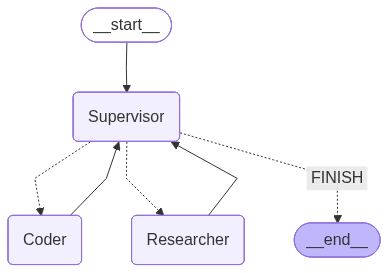

In [12]:
from IPython.display import Image, display

graph

## 5. 팀 호출 (StateGraph 방식)

완성된 그래프를 실행해요. 대한민국의 1인당 GDP 추이를 시각화하는 작업을 요청하면 Supervisor가 Researcher → Coder 순서로 작업을 분배해요.

> 💡 **실무 팁**: `recursion_limit`으로 그래프의 최대 반복 횟수를 제한할 수 있어요. 무한 루프 방지를 위해 프로덕션에서는 적절한 값을 설정하세요. 이 예제에서는 20으로 설정해요.


--- Supervisor ---
다음 실행: Researcher

--- Researcher ---
I could not find specific data for South Korea's GDP per capita between 2010 and 2025 directly from my sources. However, you can check the following resources for more detailed economic data:

1. **Economic Data Encyclopedia**: This website offers comprehensive economic data for South Korea and can provide insights into GDP per capita from 2010 to 2025. [Visit Economic Data Encyclopedia](https://economicdatagdp.com/country/kr).

2. **International Monetary Fund (IMF)**: The IMF provides various ...(생략)

--- Supervisor ---
다음 실행: Coder

--- Coder ---
다음은 2010년부터 2022년까지의 대한민국의 1인당 GDP 추세입니다 (단위: USD):

| Year | GDP per Capita (USD) |
|------|-----------------------|
| 2010 | 24,722                |
| 2011 | 25,696                |
| 2012 | 27,222                |
| 2013 | 28,834                |
| 2014 | 30,626                |
| 2015 | 31,983                |
| 2016 | 33,246                |
| 2017 | 34,827                |
| 20

<string>:18: UserWarning: Glyph 45380 (\N{HANGUL SYLLABLE NYEON}) missing from font(s) DejaVu Sans.
<string>:18: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
<string>:18: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
<string>:18: UserWarning: Glyph 45817 (\N{HANGUL SYLLABLE DANG}) missing from font(s) DejaVu Sans.
<string>:18: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
<string>:18: UserWarning: Glyph 54620 (\N{HANGUL SYLLABLE HAN}) missing from font(s) DejaVu Sans.
<string>:18: UserWarning: Glyph 48124 (\N{HANGUL SYLLABLE MIN}) missing from font(s) DejaVu Sans.
<string>:18: UserWarning: Glyph 44397 (\N{HANGUL SYLLABLE GUG}) missing from font(s) DejaVu Sans.
<string>:18: UserWarning: Glyph 52628 (\N{HANGUL SYLLABLE CU}) missing from font(s) DejaVu Sans.
<string>:18: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
/Users/elixir/dev/lect

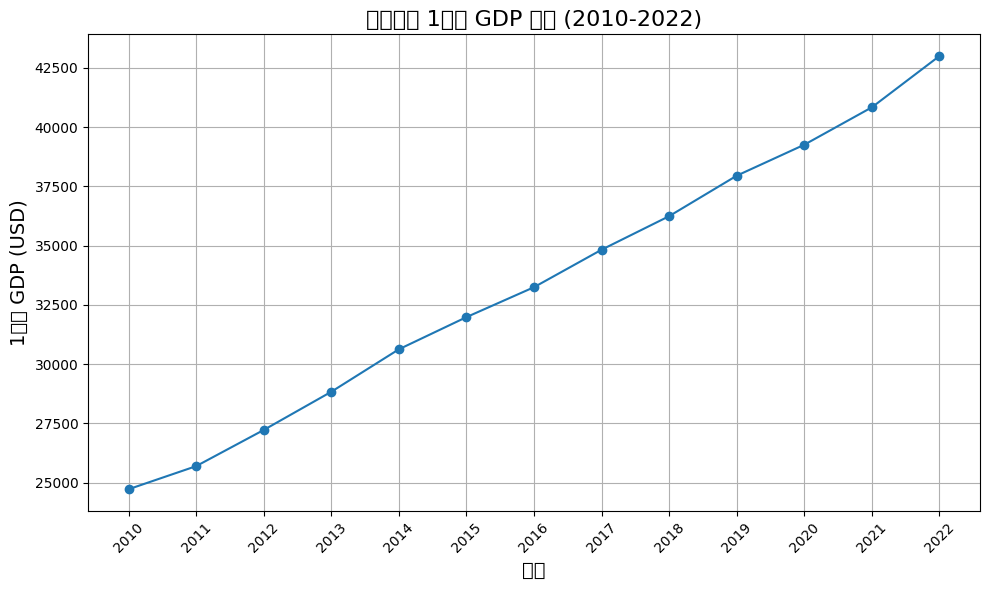


--- Coder ---
차트가 생성되었습니다. 이 차트는 2010년부터 2022년까지 대한민국의 1인당 GDP 추이를 나타내고 있습니다. x축은 연도를, y축은 1인당 GDP(USD)를 보여줍니다. 차트를 통해 부산물인 GDP의 성장 추세를 쉽게 확인할 수 있습니다.

혹시 다른 데이터 분석이나 시각화가 필요하시면 말씀해 주세요!

--- Supervisor ---
다음 실행: FINISH


In [13]:
# ---------------------------------------------------
# StateGraph 방식 실행
# ---------------------------------------------------
import uuid
from langchain_core.runnables import RunnableConfig

# 실행 설정: 재귀 한도와 고유 thread_id 설정
# thread_id: 같은 대화 세션을 구별해요
config = RunnableConfig(
    recursion_limit=20,
    configurable={"thread_id": str(uuid.uuid4())}
)

# 입력 메시지
inputs = {
    "messages": [
        HumanMessage(
            content="2010년 ~ 2025년까지의 대한민국의 1인당 GDP 추이를 조사하고 데이터를 출력해주세요."
        )
    ],
}

# 그래프를 스트리밍 방식으로 실행하고 노드별 결과를 출력
# === Multi-Agent Supervisor 실행 시작 ===
for chunk in graph.stream(inputs, config, stream_mode="updates"):
    for node_name, node_output in chunk.items():
        print(f"\n--- {node_name} ---")
        if "messages" in node_output:
            for msg in node_output["messages"]:
                if hasattr(msg, "content") and msg.content:
                    # 긴 출력은 처음 500자만 표시
                    content_preview = msg.content[:500]
                    if len(msg.content) > 500:
                        content_preview += "...(생략)"
                    print(content_preview)
        elif "next" in node_output:
            # Supervisor의 라우팅 결정 출력
            print(f"다음 실행: {node_output['next']}")

# === 실행 완료 ===

## 6. Agent-as-Tool 패턴 (간결한 구현)

앞서 구현한 StateGraph 방식은 명시적이지만 코드가 길어요. **Agent-as-Tool 패턴**을 사용하면 동일한 Supervisor 시스템을 훨씬 간결하게 만들 수 있어요.

> 💡 **핵심 정리**: StateGraph 방식과 Agent-as-Tool 방식의 차이는 **수동 기어 자동차 vs 자동 기어 자동차**와 같아요. 수동(StateGraph)은 정밀한 제어가 가능하지만 복잡하고, 자동(Agent-as-Tool)은 간편하지만 세밀한 조절이 어려워요. 처음 시작할 때는 자동(Agent-as-Tool)으로 빠르게 프로토타입을 만들고, 필요한 경우에 수동(StateGraph)으로 전환하세요.

### Agent-as-Tool의 핵심 아이디어

```python
# Sub-Agent를 @tool로 래핑하면...
@tool
def research(request: str) -> str:
    """웹에서 정보를 검색합니다."""
    result = research_agent.invoke({"messages": [{"role": "user", "content": request}]})
    return result["messages"][-1].content

# Supervisor는 create_agent로 간단하게 생성 가능해요
supervisor = create_agent(model, tools=[research, code_execution], ...)
```

| 비교 항목 | StateGraph 방식 | Agent-as-Tool 방식 |
|-----------|----------------|-------------------|
| **상태 정의** | `AgentState` 직접 정의 | `create_agent`가 자동 생성 |
| **라우팅 로직** | `RouteResponse` + `add_conditional_edges` | LLM 도구 호출로 자동 라우팅 |
| **그래프 구성** | 노드/엣지 수동 연결 | `create_agent` 한 줄로 완성 |
| **에이전트 추가** | 노드, 엣지, 멤버 목록 모두 수정 | `@tool` 래핑 후 도구 목록에 추가 |
| **제어 수준** | 높음 (세밀한 흐름 제어) | 낮음 (LLM에 위임) |
| **적합한 경우** | 복잡한 워크플로우, 커스텀 라우팅 | 빠른 프로토타이핑, 간단한 구조 |

> ⚠️ **자주 하는 실수**: Agent-as-Tool 방식에서 `@tool` 데코레이터의 **docstring이 Supervisor의 라우팅 판단 기준**이 된다는 점을 놓치기 쉬워요. LLM이 docstring을 읽고 어떤 도구를 선택할지 결정해요. docstring이 모호하면 잘못된 에이전트가 호출될 수 있으므로, 명확하고 구체적으로 작성하세요.

In [14]:
# ---------------------------------------------------
# Agent-as-Tool 패턴 구현
# ---------------------------------------------------
from langchain.tools import tool
from langchain.agents import create_agent
from langgraph.checkpoint.memory import MemorySaver


# Research Agent를 @tool로 래핑해요
# docstring이 Supervisor가 이 도구를 선택하는 기준이 돼요
@tool
def research(request: str) -> str:
    """웹에서 정보를 검색하고 조사합니다. 데이터 수집, 최신 정보 확인, 사실 조사 등에 활용합니다."""
    result = research_agent.invoke(
        {"messages": [{"role": "user", "content": request}]}
    )
    return result["messages"][-1].content


# Coder Agent를 @tool로 래핑해요
@tool
def code_execution(request: str) -> str:
    """Python 코드를 작성하고 실행합니다. 데이터 분석, 수치 계산, 차트 생성, 시각화 등에 활용합니다."""
    result = coder_agent.invoke(
        {"messages": [{"role": "user", "content": request}]}
    )
    return result["messages"][-1].content


# Supervisor Agent 생성: Sub-Agent 도구만 전달하면 OK
# StateGraph, AgentState, RouteResponse, conditional_map이 필요 없어요!
simple_supervisor = create_agent(
    model,
    tools=[research, code_execution],
    system_prompt=(
        "You are a supervisor managing research and coding tasks. "
        "Use the research tool to search the web for information and data. "
        "Use the code_execution tool to write and execute Python code for analysis and visualization. "
        "Coordinate these tools to fulfill the user's request step by step."
    ),
    checkpointer=MemorySaver(),
)

# Agent-as-Tool 방식 Supervisor 생성 완료
# StateGraph 없이 create_agent 한 번으로 완성됐어요


--- model ---

--- tools ---
Here is the GDP per capita data for South Korea from 2010 to the projected figures for 2025:

| Year | GDP per Capita (in USD) |
|------|--------------------------|
| 2010 | 24,070                   |
| 2011 | 26,180                   |
| 2012 | 26,600                   |
| 2013 | 28,450                   |
| 2014 | 30,670                   |
| 2015 | 30,170                   |
| 2016 | 30,830                   |
| 2017 | 33,300                   |
| 2018 | 35,360                   |
| 2019 | 33...(생략)

--- model ---


<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

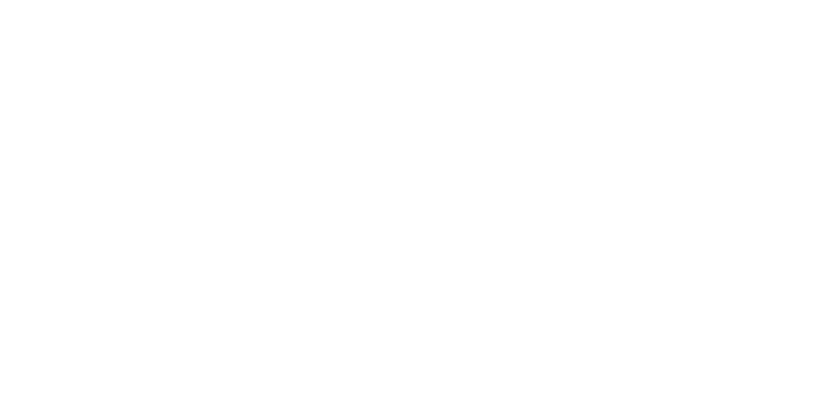

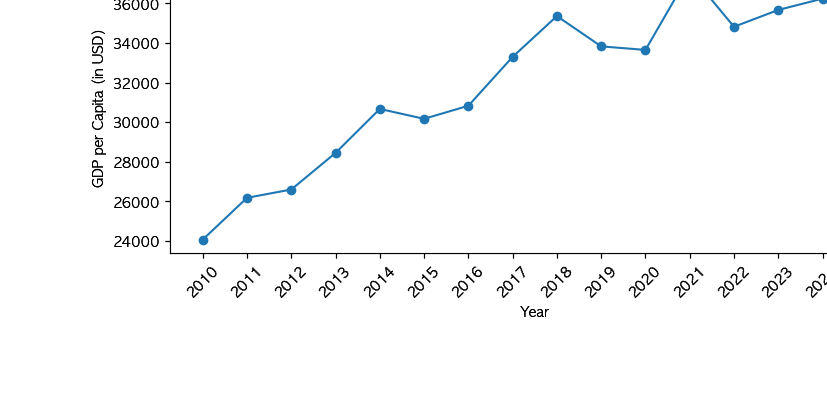


--- tools ---
The code to visualize South Korea's GDP per capita from 2010 to 2025 has been executed successfully. However, the graphic output is not displayed in this environment. If you run the provided code in your local Python environment, you should see a line plot that displays the GDP per capita over the specified years.

Here's a brief summary of the code:

1. It imports necessary libraries (Matplotlib for plotting and Pandas for data handling).
2. It creates a DataFrame with GDP per capita data from ...(생략)

--- model ---
I have gathered the GDP per capita data for South Korea from 2010 to 2025 and visualized it using a line plot. Below is the data:

| Year | GDP per Capita (in USD) |
|------|--------------------------|
| 2010 | 24,070                   |
| 2011 | 26,180                   |
| 2012 | 26,600                   |
| 2013 | 28,450                   |
| 2014 | 30,670                   |
| 2015 | 30,170                   |
| 2016 | 30,830                   |
| 2017 |

In [15]:
# ---------------------------------------------------
# Agent-as-Tool 방식 실행
# ---------------------------------------------------
# 동일한 요청으로 StateGraph 방식과 결과를 비교해보세요
config_simple = RunnableConfig(
    recursion_limit=10,
    configurable={"thread_id": str(uuid.uuid4())}
)

# 동일한 입력 메시지
inputs_simple = {
    "messages": [
        HumanMessage(
            content="2010년 ~ 2025년까지의 대한민국의 1인당 GDP 추이를 조사하고 데이터를 출력해주세요."
        )
    ],
}

# === Agent-as-Tool 방식 실행 시작 ===
for chunk in simple_supervisor.stream(inputs_simple, config_simple, stream_mode="updates"):
    for node_name, node_output in chunk.items():
        print(f"\n--- {node_name} ---")
        if "messages" in node_output:
            for msg in node_output["messages"]:
                if hasattr(msg, "content") and msg.content:
                    content_preview = msg.content[:500]
                    if len(msg.content) > 500:
                        content_preview += "...(생략)"
                    print(content_preview)

# === 실행 완료 ===

## 7. 실습: 새 Worker 추가해보기

아래 TODO 블록을 완성해 **Writer** Worker를 팀에 추가해보세요. Writer는 Researcher가 수집한 데이터를 바탕으로 보고서를 작성하는 에이전트예요.

> 💡 **실무 팁**: StateGraph 방식에서 새 에이전트를 추가할 때는 (1) `members` 목록에 추가, (2) 노드 생성 및 등록, (3) `conditional_map` 업데이트 세 가지 작업이 모두 필요해요. Agent-as-Tool 방식은 `@tool` 래핑 후 도구 목록에 추가하면 끝이에요.

=== 3-Worker (Researcher + Coder + Writer) 실행 시작 ===

--- model ---

--- tools ---
Here are the trends and data on South Korea's GDP per capita from 2010 to 2025:

### GDP Per Capita
- **2010**: $24,040
- **2011**: $27,614
- **2012**: $29,549
- **2013**: $31,123
- **2014**: $32,281
- **2015**: $30,172
- **2016**: $30,826
- **2017**: $33,297
- **2018**: $35,364
- **2019**: $33,827
- **2020**: $31,721
- **2021**: $35,126
- **2022**: $32,395
- **2023**: $33,121
- **2024**: Projected around $36,239
- **2025**: Projected around $36,227
- **2026**: Projected around $37,412

#### Key...(생략)

--- model ---


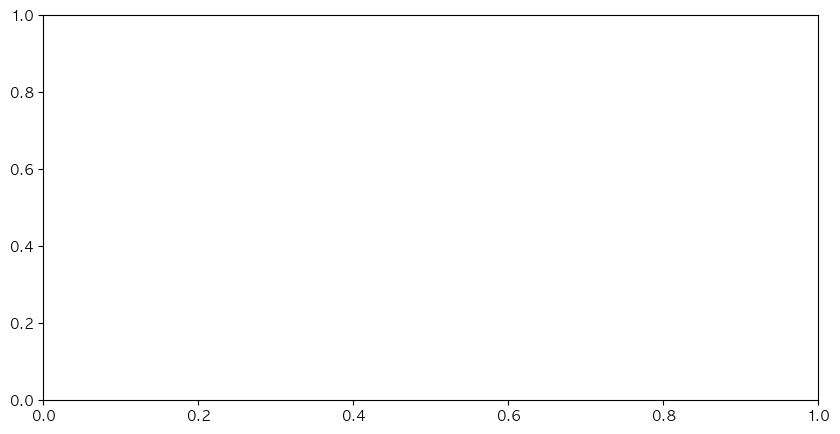

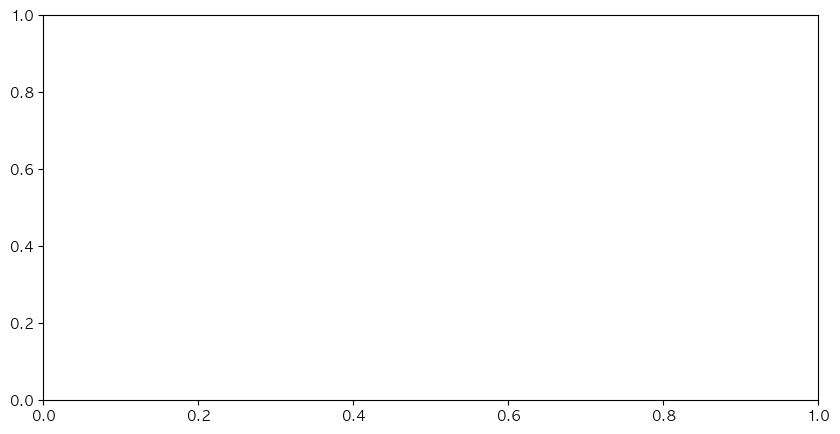

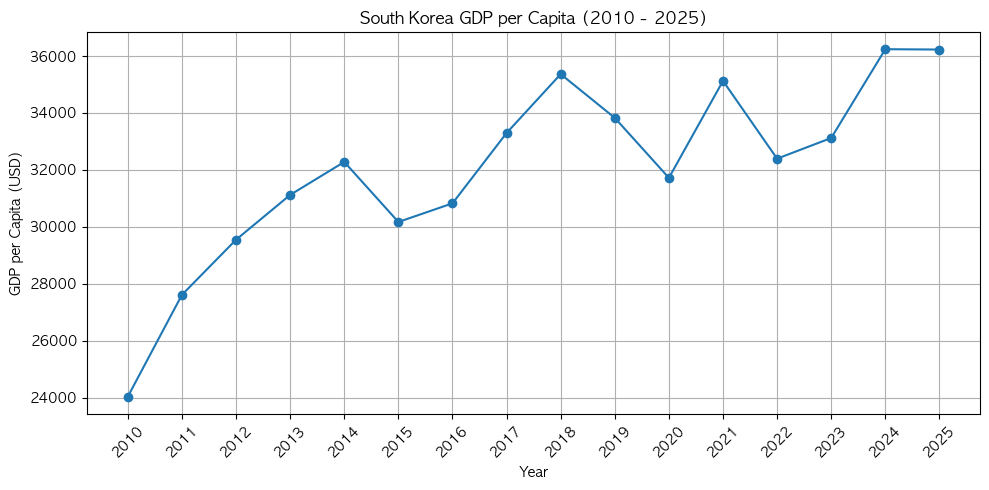


--- tools ---
The graph for South Korea's GDP per capita from 2010 to 2025 has been generated successfully. It shows a trend with years on the x-axis and GDP per capita (in USD) on the y-axis. If you need any specific analysis or further exploration of the data, please let me know!

--- model ---

--- tools ---
# 한국의 1인당 GDP 추세 보고서 (2010 - 2025)

## 서론
이 보고서는 2010년부터 2025년까지 한국의 1인당 GDP 추세를 개괄하며, 주요 관찰 사항과 예상 성장률을 강조합니다.

## 1인당 GDP 데이터
다음은 지정된 연도에 대한 한국의 1인당 GDP 수집 데이터입니다:

| 연도 | 1인당 GDP (USD) |
|------|------------------|
| 2010 | $24,040          |
| 2011 | $27,614          |
| 2012 | $29,549          |
| 2013 | $31,123          |
| 2014 | $32,281          |
| 2015 | $30,172          |
| 2016 | $30,826          |
| 2017 | $33,297          |
| 2018 | $35,364          |
| 2019 | $33,827          |
| ...(생략)

--- model ---
보고서가 성공적으로 작성되었습니다. 아래는 한국의 1인당 GDP 추세(2010 - 2025)에 대한 요약입니다.

---

# 한국의 1인당 GDP 추세 보고서 (2010 - 2025)

## 서론
이 보고서는 2010년부터 2025년까지 한국의 1인당 GDP 추세를 개괄하며, 주요 관찰 사

In [18]:
# TODO: 이 셀의 핵심 구현 코드를 수업 시간에 직접 작성하세요.
# 목표: Agent-as-Tool 방식으로 Writer 에이전트를 추가해보세요
# 위 마크다운 설명과 힌트를 참고해 필요한 타입, 함수, 그래프 구성, 실행 코드를 완성하세요.

writer_agent = create_agent(
    model="openai:gpt-4o-mini",
    tools=[],
    system_prompt=(
        "너는 전문 리포터야"
        "Your task is to organize, summarize, and write a clean and structured report "
        "based on the data and research results provided to you."
        "무조건 한국어로 작성한다."
    )
)

@tool
def write_report(request: str) -> str:
    """
    수집된 조사 자료와 데이터를 바탕으로 보고서를 깔끔하게 작성하고 요약한다.
    최종 보고서 작성 요약 문맥 정리 등에 활용한다.
    """

    result = writer_agent.invoke(
        {"messages": [HumanMessage(content=request)]}
    )
    return result["messages"][-1].content

new_supervisor = create_agent(
    model=model,
    tools=[research, code_execution, write_report],
    system_prompt=(
        "You are a supervisor managing a research, coding, and report writing team. "
        "Use the research tool to search the web for information and data. "
        "Use the code_execution tool to write and execute Python code for analysis and visualization. "
        "Use the write_report tool to compile the collected information and data into a structured report. "
        "Coordinate these tools to fulfill the user's request step by step."
    ),
    checkpointer=MemorySaver(),
)

config_new = RunnableConfig(
    recursion_limit=15,
    configurable={"thread_id": str(uuid.uuid4())}
)

inputs_new = {
    "messages": [
        HumanMessage(
            content="2010년 ~ 2025년까지의 대한민국의 1인당 GDP 추이를 조사하고 데이터를 출력해주세요."
        )
    ]
}

print("=== 3-Worker (Researcher + Coder + Writer) 실행 시작 ===")
for chunk in new_supervisor.stream(inputs_new, config_new, stream_mode="updates"):
    for node_name, node_output in chunk.items():
        print(f"\n--- {node_name} ---")
        if "messages" in node_output:
            for msg in node_output["messages"]:
                if hasattr(msg, "content") and msg.content:
                    content_preview = msg.content[:500]
                    if len(msg.content) > 500:
                        content_preview += "...(생략)"
                    print(content_preview)



## 핵심 요약

이 노트북에서 다음 내용을 배웠어요:

- **`AgentState`**: `messages`(누적 방식) + `next`(라우팅 대상)로 구성된 멀티 에이전트 공유 상태예요. `operator.add` reducer가 메시지를 덮어쓰지 않고 누적시켜요.

- **`RouteResponse`**: `Literal[*options]` 타입으로 Supervisor의 응답을 유효한 선택지로 제한해요. `model.with_structured_output(RouteResponse)`가 핵심이에요.

- **`agent_node` + `functools.partial`**: 하나의 어댑터 함수를 여러 에이전트에 재사용하는 패턴이에요. `partial`로 `agent`와 `name`을 고정하면 노드 함수를 간결하게 만들 수 있어요.

- **StateGraph 방식**: `add_conditional_edges` + `conditional_map`으로 명시적 라우팅을 구현해요. 복잡한 워크플로우와 커스텀 흐름 제어에 적합해요.

- **Agent-as-Tool 방식**: 에이전트를 `@tool`로 래핑하고 `create_agent`로 Supervisor를 만들어요. 코드가 간결하고 에이전트 추가가 쉬워 빠른 프로토타이핑에 적합해요.

## 02-Supervisor vs 04-Multi-Agent-Supervisor — 실전 선택 기준

| 상황 | 추천 방식 | 이유 |
|------|----------|------|
| 에이전트 간 이동 시 **state 수정·메시지 삽입**이 필요 | **02 (핸드오프 도구)** | `Command(goto=..., update=...)`로 상태 전환을 한 호출에 담을 수 있어요 |
| Task description 같은 **명시적 작업 브리프** 전달 | **02 (핸드오프 도구)** | `Send` 패턴으로 부모 히스토리와 자식 입력을 분리할 수 있어요 |
| Supervisor 결정 로그를 **엄격한 enum**으로 관찰·디버깅 | **04 (구조화 출력)** | `Literal` 타입이 라우팅 값 오염을 컴파일 시점에서 차단해요 |
| **Tool calling이 불안정하거나 지원되지 않는 모델** 사용 | **04 (구조화 출력)** | 구조화 출력만으로 동작하므로 도구 호환 문제에서 자유로워요 |
| 새 Worker 추가 빈도가 매우 높은 **빠른 프로토타이핑** | **04의 Agent-as-Tool 형태** | `@tool` 래핑 한 번으로 끝, `members`/`conditional_map` 동기화 부담이 없어요 |

> 💡 **핵심 정리**: 두 방식은 배타적이지 않아요. 실제 프로덕션에서는 상위 Supervisor는 핸드오프 도구 방식(복잡한 handoff), 하위 Sub-Supervisor는 구조화 출력 방식(단순 라우팅)처럼 **계층별로 섞어 쓰는** 경우가 많아요. 08-Hierarchical-Agent에서 이 조합을 다시 만나게 돼요.

## 다음 노트북 예고

다음 `05-Handoffs.ipynb`에서는 **Handoffs 패턴**을 배워요. Supervisor처럼 중앙 라우팅 에이전트를 두지 않고, 상태 변수(`current_step`)로 에이전트 행동을 **직접 제어**해요. LLM 라우팅 비용 없이 예측 가능한 워크플로우를 만들 수 있어서, 공항 체크인 → 보안 → 탑승구처럼 단계가 명확한 시나리오에 적합해요.